# 03 — Exploratory Data Analysis
Before building any model, we explore the data to understand patterns, spot issues, and form hypotheses about what drives Padres attendance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/padres_master.csv")
df["date"] = pd.to_datetime(df["date"])
df["attendance"] = df["attendance"].astype(int)

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Shape: (320, 10)
Date range: 2022-04-14 to 2025-09-28


,date,season,opponent,home_score,away_score,attendance,status,game_pk,avg_temp_f,avg_precip_mm
0,2022-04-14,2022,Atlanta Braves,12,1,44844,Final,662237,61.3,0.0
1,2022-04-15,2022,Atlanta Braves,2,5,41993,Final,662236,62.6,0.0
2,2022-04-16,2022,Atlanta Braves,2,5,36924,Final,662235,62.8,0.0
3,2022-04-17,2022,Atlanta Braves,2,1,37694,Final,662234,62.5,0.0
4,2022-04-18,2022,Cincinnati Reds,4,1,31121,Final,662233,63.6,0.0


## Data Quality Check
Check for missing values and basic stats before diving into visualizations.

In [3]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Attendance summary:")
print(df["attendance"].describe().round(0))

Missing values:
date             0
season           0
opponent         0
home_score       0
away_score       0
attendance       0
status           0
game_pk          0
avg_temp_f       0
avg_precip_mm    0
dtype: int64

Attendance summary:
count      320.0
mean     40420.0
std       4402.0
min      23828.0
25%      38174.0
50%      41841.0
75%      43408.0
max      47559.0
Name: attendance, dtype: float64


## Attendance Distribution
How spread out is attendance? Is it normally distributed or skewed?

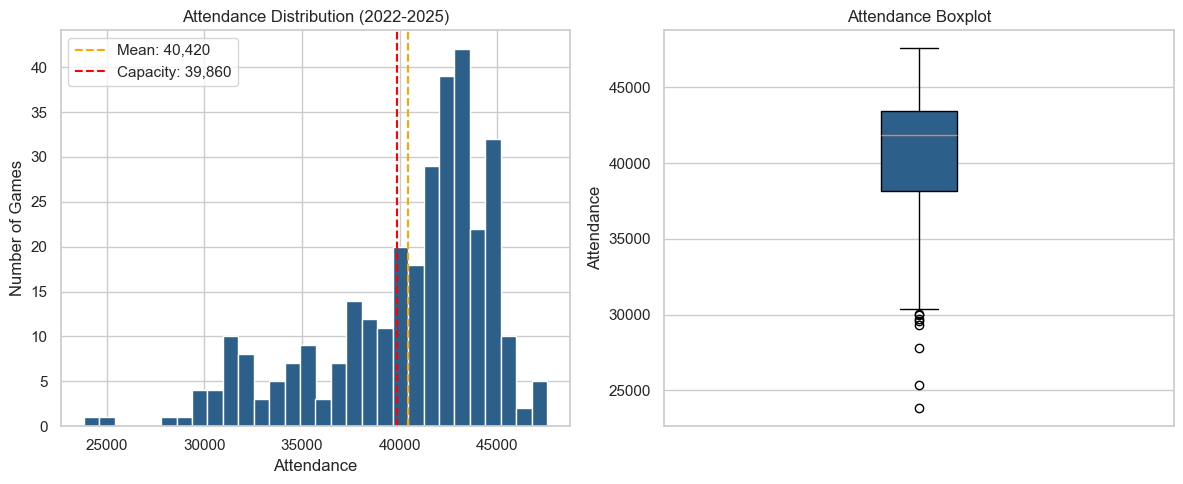

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["attendance"], bins=30, color="#2C5F8A", edgecolor="white")
axes[0].axvline(df["attendance"].mean(), color="orange", linestyle="--", label=f"Mean: {df['attendance'].mean():,.0f}")
axes[0].axvline(39860, color="red", linestyle="--", label="Capacity: 39,860")
axes[0].set_xlabel("Attendance")
axes[0].set_ylabel("Number of Games")
axes[0].set_title("Attendance Distribution (2022-2025)")
axes[0].legend()

axes[1].boxplot(df["attendance"], patch_artist=True, boxprops=dict(facecolor="#2C5F8A"))
axes[1].set_ylabel("Attendance")
axes[1].set_title("Attendance Boxplot")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## Attendance by Season
Did attendance trend up or down year over year?

         mean  median    min    max
season                             
2022    36882   37694  23828  44930
2023    40915   42525  29581  45116
2024    41487   42037  32227  47559
2025    42435   42706  33885  47345


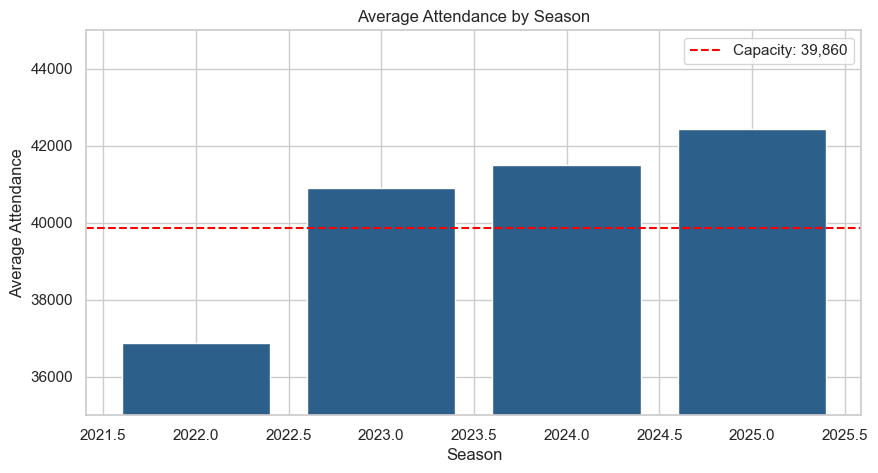

In [6]:
season_stats = df.groupby("season")["attendance"].agg(["mean", "median", "min", "max"]).round(0).astype(int)
print(season_stats)

season_means = df.groupby("season")["attendance"].mean()
plt.bar(season_means.index, season_means.values, color="#2C5F8A", edgecolor="white")
plt.axhline(39860, color="red", linestyle="--", label="Capacity: 39,860")
plt.xlabel("Season")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Season")
plt.legend()
plt.ylim(35000, 45000)
plt.show()

## Attendance by Day of Week
Weekend games typically draw more fans — let's confirm this in the data.

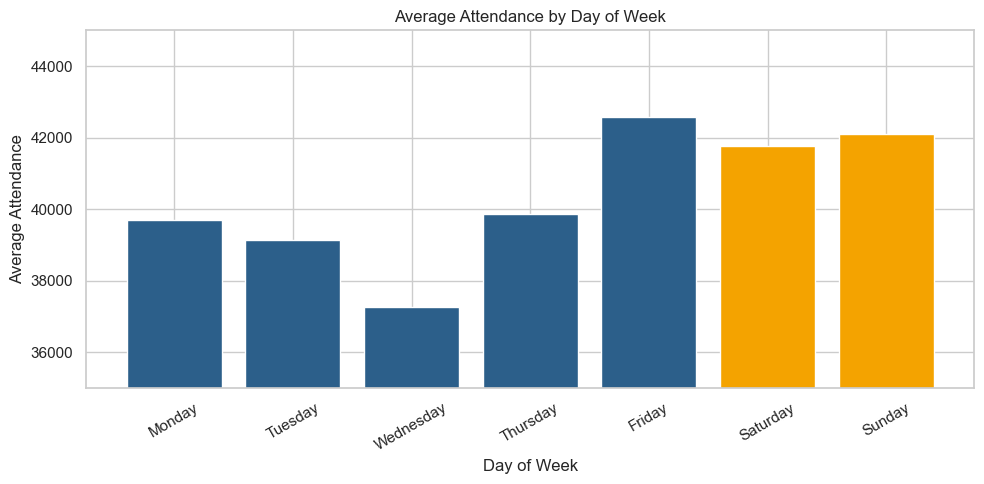

day_of_week
Monday       39687
Tuesday      39134
Wednesday    37267
Thursday     39869
Friday       42583
Saturday     41774
Sunday       42111
Name: attendance, dtype: int64


In [7]:
df["day_of_week"] = df["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_avg = df.groupby("day_of_week")["attendance"].mean().reindex(day_order)

colors = ["#2C5F8A" if d not in ["Saturday", "Sunday"] else "#F4A300" for d in day_order]
plt.bar(day_avg.index, day_avg.values, color=colors, edgecolor="white")
plt.xlabel("Day of Week")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Day of Week")
plt.xticks(rotation=30)
plt.ylim(35000, 45000)
plt.tight_layout()
plt.show()

print(day_avg.round(0).astype(int))

## Attendance by Month
Summer months and playoff races tend to boost attendance.

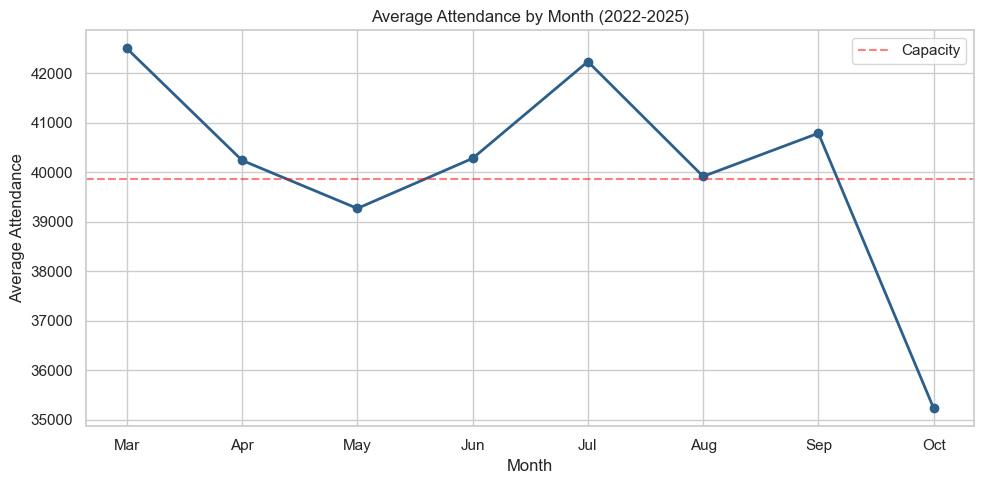

In [8]:
df["month"] = df["date"].dt.month
month_names = {3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct"}

month_avg = df.groupby("month")["attendance"].mean()
month_avg.index = month_avg.index.map(month_names)

plt.plot(month_avg.index, month_avg.values, marker="o", color="#2C5F8A", linewidth=2)
plt.axhline(39860, color="red", linestyle="--", alpha=0.5, label="Capacity")
plt.xlabel("Month")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Month (2022-2025)")
plt.legend()
plt.tight_layout()
plt.show()

## Top and Bottom Opponents by Attendance
Rivalry games and marquee opponents draw bigger crowds.

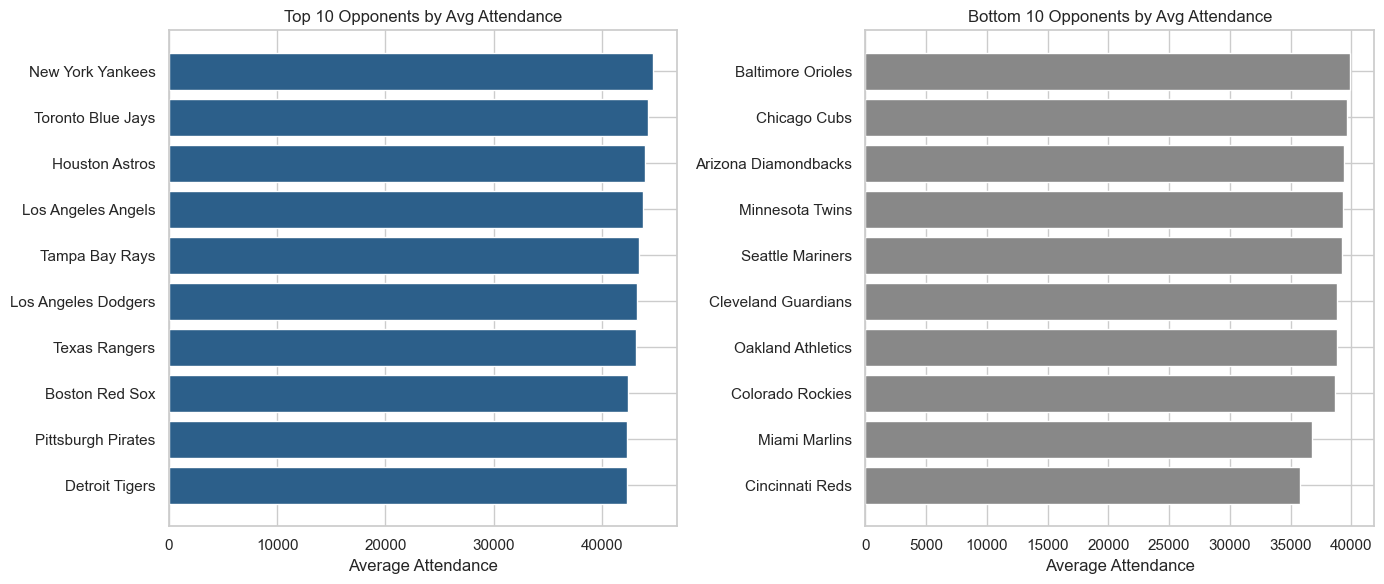

In [9]:
opponent_avg = df.groupby("opponent")["attendance"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10 = opponent_avg.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color="#2C5F8A")
axes[0].set_title("Top 10 Opponents by Avg Attendance")
axes[0].set_xlabel("Average Attendance")

bot10 = opponent_avg.tail(10)
axes[1].barh(bot10.index[::-1], bot10.values[::-1], color="#888")
axes[1].set_title("Bottom 10 Opponents by Avg Attendance")
axes[1].set_xlabel("Average Attendance")

plt.tight_layout()
plt.show()

## Weather vs. Attendance
San Diego has mild weather year-round, but temperature and rain might still matter at the margins.

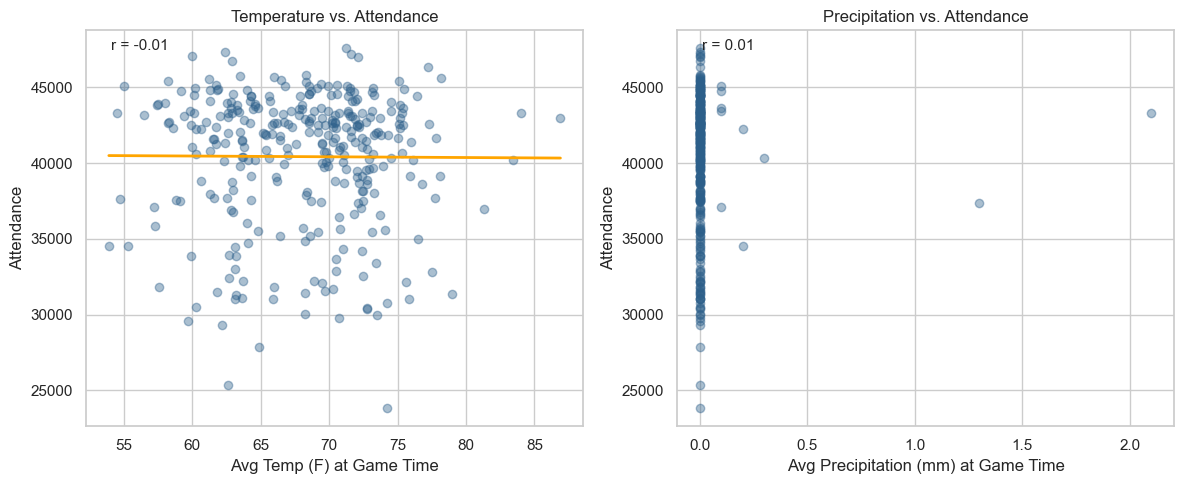

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

weather = df.dropna(subset=["avg_temp_f"])
axes[0].scatter(weather["avg_temp_f"], weather["attendance"], alpha=0.4, color="#2C5F8A")
z = np.polyfit(weather["avg_temp_f"], weather["attendance"], 1)
p = np.poly1d(z)
x_line = np.linspace(weather["avg_temp_f"].min(), weather["avg_temp_f"].max(), 100)
axes[0].plot(x_line, p(x_line), color="orange", linewidth=2)
axes[0].set_xlabel("Avg Temp (F) at Game Time")
axes[0].set_ylabel("Attendance")
axes[0].set_title("Temperature vs. Attendance")
corr_temp = weather[["avg_temp_f", "attendance"]].corr().iloc[0, 1]
axes[0].text(0.05, 0.95, f"r = {corr_temp:.2f}", transform=axes[0].transAxes, fontsize=11)

axes[1].scatter(df["avg_precip_mm"], df["attendance"], alpha=0.4, color="#2C5F8A")
axes[1].set_xlabel("Avg Precipitation (mm) at Game Time")
axes[1].set_ylabel("Attendance")
axes[1].set_title("Precipitation vs. Attendance")
corr_precip = df[["avg_precip_mm", "attendance"]].corr().iloc[0, 1]
axes[1].text(0.05, 0.95, f"r = {corr_precip:.2f}", transform=axes[1].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

## Correlation Summary
Quick look at which numeric variables correlate most with attendance. This will guide feature selection in the modeling notebook.

Correlation with attendance:
               attendance
season              0.441
is_weekend          0.378
dayofweek           0.306
avg_precip_mm       0.012
month              -0.002
avg_temp_f         -0.006


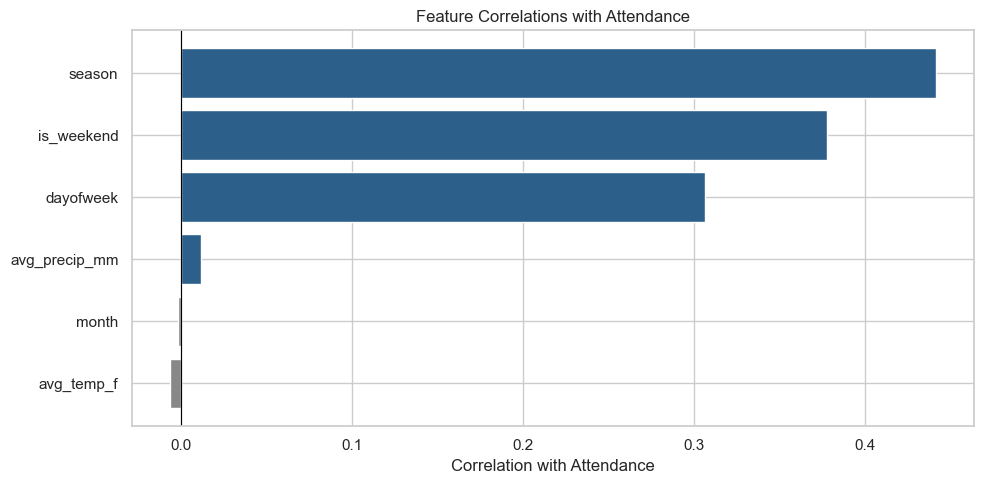

In [12]:
df["dayofweek"] = df["date"].dt.dayofweek  # 0=Monday, 6=Sunday
df["is_weekend"] = df["dayofweek"].isin([4, 5, 6]).astype(int)  # Fri/Sat/Sun

numeric_cols = ["attendance", "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm"]
corr = df[numeric_cols].corr()[["attendance"]].drop("attendance").sort_values("attendance", ascending=False)

print("Correlation with attendance:")
print(corr.round(3))

colors = ["#2C5F8A" if v > 0 else "#888" for v in corr["attendance"].values[::-1]]
plt.barh(corr.index[::-1], corr["attendance"].values[::-1], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Attendance")
plt.title("Feature Correlations with Attendance")
plt.tight_layout()
plt.show()

## Game Time: Day Games vs. Night Games
Wednesday attendance looked low — but Wednesday has both day games (1:10pm) and night games (6:40pm). We pull game start times from the MLB API to test whether the drop is about the *day* or the *time*.

In [16]:
import requests
TEAM_ID = 135
SEASONS = [2022, 2023, 2024, 2025]

# Fetch game start times from schedule API (gameDate field is UTC)
# San Diego games are in Pacific Daylight Time (UTC-7) for the entire baseball season
def get_game_times(team_id, seasons):
    times = {}
    for season in seasons:
        url = "https://statsapi.mlb.com/api/v1/schedule"
        params = {"sportId": 1, "season": season, "gameType": "R",
                  "teamId": team_id, "hydrate": "linescore,team"}
        data = requests.get(url, params=params).json()
        for date in data.get("dates", []):
            for game in date.get("games", []):
                if game["teams"]["home"]["team"]["id"] == team_id:
                    game_dt_str = game.get("gameDate", "")
                    if game_dt_str:
                        dt = pd.to_datetime(game_dt_str, utc=True)
                        # Convert UTC to Pacific (UTC-7 during baseball season)
                        hour_pt = (dt.hour - 7) % 24
                        minute_pt = dt.minute
                        times[game["gamePk"]] = hour_pt + minute_pt / 60
    return times

print("Fetching game times...")
game_times = get_game_times(TEAM_ID, SEASONS)
df["game_hour_pt"] = df["game_pk"].map(game_times)
df["is_day_game"] = (df["game_hour_pt"] < 17).astype(int)  # before 5pm = day game

print(f"Day games:   {df['is_day_game'].sum()}")
print(f"Night games: {(df['is_day_game'] == 0).sum()}")
print()

# What time do games actually start?
print("Most common start hours (PT):")
print(df["game_hour_pt"].round(1).value_counts().sort_index())

Fetching game times...
Day games:   113
Night games: 207

Most common start hours (PT):
game_hour_pt
12.2      2
13.1      2
13.2     83
14.2      1
14.5      1
15.7     12
16.1      1
16.2     10
16.6      1
17.2      1
17.7     37
18.2      2
18.7    158
19.1      1
19.2      8
Name: count, dtype: int64


In [ ]:
# Check game dates and opponents for weird game times to investigate why
odd_times = df[(df["game_hour_pt"] >= 15) & (df["game_hour_pt"] < 17)]
print(odd_times[["date", "opponent", "game_hour_pt"]].to_string())

          date               opponent  game_hour_pt
3   2022-04-17         Atlanta Braves     16.133333
37  2022-07-04       Seattle Mariners     15.666667
41  2022-07-09   San Francisco Giants     16.250000
47  2022-07-30        Minnesota Twins     16.250000
63  2022-09-05   Arizona Diamondbacks     15.666667
99  2023-05-07    Los Angeles Dodgers     16.166667
116 2023-06-17         Tampa Bay Rays     16.250000
122 2023-07-04     Los Angeles Angels     15.666667
135 2023-08-06    Los Angeles Dodgers     16.166667
151 2023-09-04  Philadelphia Phillies     15.666667
168 2024-04-10           Chicago Cubs     15.666667
187 2024-05-27          Miami Marlins     15.666667
199 2024-06-22      Milwaukee Brewers     16.250000
208 2024-07-10       Seattle Mariners     15.666667
210 2024-07-13         Atlanta Braves     16.250000
222 2024-08-21        Minnesota Twins     15.666667
227 2024-09-02         Detroit Tigers     15.666667
235 2024-09-18         Houston Astros     15.666667
241 2025-03-

## Game Time Buckets
Not all non-weekend games are equal. A 1:10pm Wednesday game conflicts with a full workday; a 6:40pm Tuesday game only conflicts with commute. We bucket start times into three categories and look at weekday attendance by bucket.

In [21]:
def time_bucket(hour):
    if hour < 17:
        return "Early (<5pm)"
    elif hour < 18.5:
        return "Twilight (5-6:30pm)"
    else:
        return "Night (6:30pm+)"

df["time_bucket"] = df["game_hour_pt"].apply(time_bucket)

# Overall counts
print("Games per time bucket:")
print(df["time_bucket"].value_counts())
print()
print("Average attendance per time bucket:")
print(df.groupby("time_bucket")["attendance"].mean().round(0).astype(int))


Games per time bucket:
time_bucket
Night (6:30pm+)        167
Early (<5pm)           113
Twilight (5-6:30pm)     40
Name: count, dtype: int64

Average attendance per time bucket:
time_bucket
Early (<5pm)           39376
Night (6:30pm+)        40607
Twilight (5-6:30pm)    42591
Name: attendance, dtype: int64


Weekday average attendance by time bucket:
time_bucket  Early (<5pm)  Twilight (5-6:30pm)  Night (6:30pm+)
day_of_week                                                    
Monday              41298                42250            39231
Tuesday             33210                 <NA>            39638
Wednesday           35567                41942            41284
Thursday            38686                42310            39769
Friday              45114                 <NA>            42532



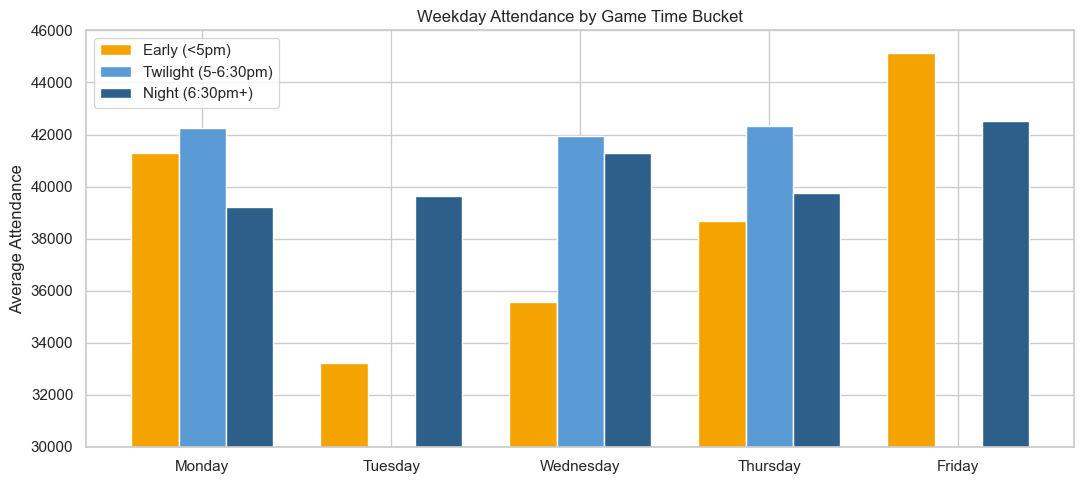

In [23]:
# Weekday-only breakdown by time bucket
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wd = df[df["day_of_week"].isin(weekdays)].copy()

bucket_order = ["Early (<5pm)", "Twilight (5-6:30pm)", "Night (6:30pm+)"]
pivot = wd.groupby(["day_of_week", "time_bucket"])["attendance"].mean().unstack()
pivot = pivot.reindex(index=weekdays, columns=bucket_order)

print("Weekday average attendance by time bucket:")
print(pivot.round(0).astype("Int64"))
print()

# Chart
x = np.arange(len(weekdays))
width = 0.25
colors = ["#F4A300", "#5B9BD5", "#2C5F8A"]
fig, ax = plt.subplots(figsize=(11, 5))
for i, (bucket, color) in enumerate(zip(bucket_order, colors)):
    vals = pivot[bucket].fillna(0)
    ax.bar(x + (i - 1) * width, vals, width, label=bucket, color=color)
ax.set_xticks(x)
ax.set_xticklabels(weekdays)
ax.set_ylabel("Average Attendance")
ax.set_title("Weekday Attendance by Game Time Bucket")
ax.legend()
ax.set_ylim(30000, 46000)
plt.tight_layout()
plt.show()


## National Broadcasts
Games selected for national TV (ESPN, Fox, TBS, FS1, MLB Network) are picked because the matchup is compelling. That selection is itself a signal of game importance — and may predict higher ticket demand. We probe the MLB API to see what broadcast data is available.

In [25]:
# Probe: fetch one season with broadcasts hydration and inspect the structure
import requests
url = "https://statsapi.mlb.com/api/v1/schedule"
params = {"sportId": 1, "season": 2024, "gameType": "R",
          "teamId": 135, "hydrate": "broadcasts"}
sample = requests.get(url, params=params).json()

# Find first home game and print its broadcast data
for date in sample.get("dates", []):
    for game in date.get("games", []):
        if game["teams"]["home"]["team"]["id"] == 135:
            print("Sample game:", date["date"], game["teams"]["away"]["team"]["name"])
            print("Broadcasts:", game.get("broadcasts", []))
            print()
            break
    else:
        continue
    break

# Also print all unique broadcast names across the season to see what's available
all_broadcasts = set()
for date in sample.get("dates", []):
    for game in date.get("games", []):
        if game["teams"]["home"]["team"]["id"] == 135:
            for b in game.get("broadcasts", []):
                all_broadcasts.add((b.get("name"), b.get("type"), b.get("isNational")))

print("All broadcast names found in 2024:")
for b in sorted(all_broadcasts):
    print(b)


Sample game: 2024-03-20 Los Angeles Dodgers
Broadcasts: [{'id': 102, 'name': 'Dodgers Radio AM570', 'type': 'AM', 'language': 'en', 'isNational': False, 'callSign': 'KLAC AM570', 'availability': {'availabilityId': 2, 'availabilityCode': 'local_out_of_market', 'availabilityText': 'Local (Out of Market)'}, 'mediaState': {'mediaStateId': 3, 'mediaStateCode': 'MEDIA_ARCHIVE', 'mediaStateText': 'Media Archive'}, 'broadcastDate': '2024-03-20', 'mediaId': '68cde21a-56e5-42b2-b69b-e6380ae97a6b', 'gameDateBroadcastGuid': '68cde21a-56e5-42b2-b69b-e6380ae97a6b', 'homeAway': 'away', 'freeGame': False, 'availableForStreaming': True, 'postGameShow': False, 'mvpdAuthRequired': False, 'freeGameStatus': False}, {'id': 4965, 'name': 'SportsNet LA', 'type': 'TV', 'language': 'en', 'isNational': False, 'callSign': 'SNLA', 'videoResolution': {'code': 'H', 'resolutionShort': 'HD', 'resolutionFull': 'High Resolution'}, 'availability': {'availabilityId': 1, 'availabilityCode': 'local_in_market', 'availability

## National Broadcasts
Games on national TV (ESPN, FOX, FS1, Apple TV, TBS, TruTV, MLBN, Roku) are selected because the matchup is compelling. That selection is itself a demand signal — and may predict higher ticket sales independent of opponent.

In [26]:
import requests

def get_national_broadcasts(team_id, seasons):
    national = {}
    national_networks = {}
    for season in seasons:
        url = "https://statsapi.mlb.com/api/v1/schedule"
        params = {"sportId": 1, "season": season, "gameType": "R",
                  "teamId": team_id, "hydrate": "broadcasts"}
        data = requests.get(url, params=params).json()
        for date in data.get("dates", []):
            for game in date.get("games", []):
                if game["teams"]["home"]["team"]["id"] == team_id:
                    pk = game["gamePk"]
                    tv_national = [b["name"] for b in game.get("broadcasts", [])
                                   if b.get("type") == "TV" and b.get("isNational")]
                    national[pk] = 1 if tv_national else 0
                    national_networks[pk] = ", ".join(tv_national) if tv_national else None
    return national, national_networks

nat_flags, nat_networks = get_national_broadcasts(TEAM_ID, SEASONS)
df["is_national"] = df["game_pk"].map(nat_flags).fillna(0).astype(int)
df["national_network"] = df["game_pk"].map(nat_networks)

print(f"National broadcast games: {df['is_national'].sum()} / {len(df)}")
print()
print("By network:")
print(df[df["national_network"].notna()]["national_network"].value_counts())
print()
print("Average attendance — national vs. non-national:")
print(df.groupby("is_national")["attendance"].mean().round(0).astype(int))


National broadcast games: 95 / 320

By network:
national_network
MLBN (out-of-market only), MLBN (out-of-market only)    58
FS1, FS1                                                 8
FOX, FOX                                                 8
ESPN/ESPN App, ESPN/ESPN App                             5
MLBN, MLBN                                               5
Apple TV, Apple TV                                       4
TBS (out-of-market only), TBS (out-of-market only)       3
TBS (out-of-market only), TBS                            1
MLBN (out-of-market only)                                1
Roku, Roku                                               1
TruTV, TruTV                                             1
Name: count, dtype: int64

Average attendance — national vs. non-national:
is_national
0    40421
1    40418
Name: attendance, dtype: int64


## Premium National Broadcasts
MLB Network dominates the national broadcast count but selects games differently from ESPN, FOX, or Apple TV. We separate 'premium' national games (hand-picked marquee matchups) from MLBN filler to get a cleaner signal.

Premium national games: 30
MLBN-only games: 65
Non-national games: 225

Average attendance by broadcast tier:
broadcast_tier
MLBN only           39939
Non-national        40421
Premium national    41456
Name: attendance, dtype: int64



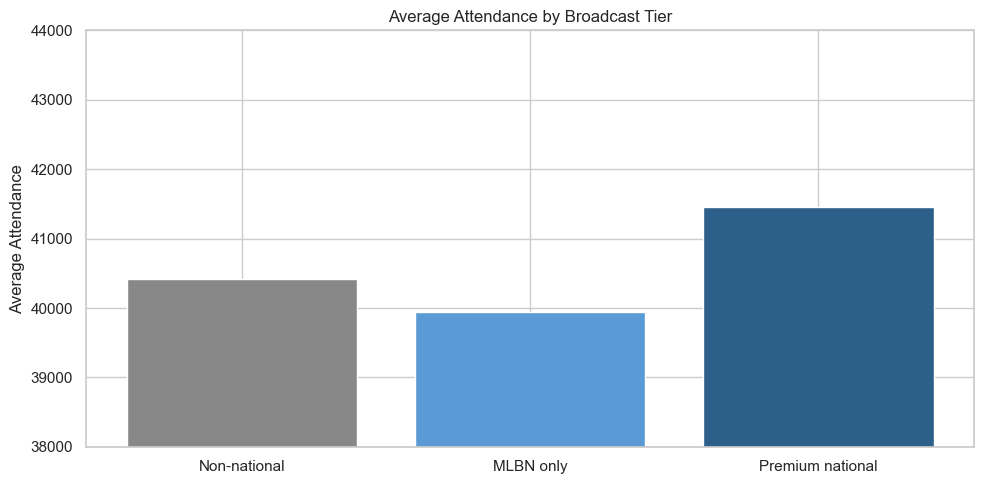

In [27]:
premium_networks = {"FOX", "FOX, FOX", "ESPN/ESPN App", "ESPN/ESPN App, ESPN/ESPN App",
                    "Apple TV", "Apple TV, Apple TV", "TBS (out-of-market only)",
                    "TBS (out-of-market only), TBS (out-of-market only)",
                    "TBS (out-of-market only), TBS", "Roku", "Roku, Roku",
                    "FS1", "FS1, FS1"}

df["is_premium_national"] = df["national_network"].isin(premium_networks).astype(int)

print("Premium national games:", df["is_premium_national"].sum())
print("MLBN-only games:", df["is_national"].sum() - df["is_premium_national"].sum())
print("Non-national games:", (df["is_national"] == 0).sum())
print()
print("Average attendance by broadcast tier:")
tier_map = {(0, 0): "Non-national", (1, 0): "MLBN only", (1, 1): "Premium national"}
df["broadcast_tier"] = list(zip(df["is_national"], df["is_premium_national"]))
df["broadcast_tier"] = df["broadcast_tier"].map(tier_map)
print(df.groupby("broadcast_tier")["attendance"].mean().round(0).astype(int))
print()

# Bar chart
tier_order = ["Non-national", "MLBN only", "Premium national"]
tier_avg = df.groupby("broadcast_tier")["attendance"].mean().reindex(tier_order)
colors = ["#888", "#5B9BD5", "#2C5F8A"]
plt.bar(tier_avg.index, tier_avg.values, color=colors, edgecolor="white")
plt.ylabel("Average Attendance")
plt.title("Average Attendance by Broadcast Tier")
plt.ylim(38000, 44000)
plt.tight_layout()
plt.show()


## Game Time by Day of Week — Full Breakdown (All Days)
Extending the day/time analysis to weekends. Counts shown alongside averages so we can flag cells with too few games to draw conclusions from.

In [29]:
all_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
bucket_order = ["Early (<5pm)", "Twilight (5-6:30pm)", "Night (6:30pm+)"]

avg_pivot = df.groupby(["day_of_week", "time_bucket"])["attendance"].mean().unstack().reindex(index=all_days, columns=bucket_order)
count_pivot = df.groupby(["day_of_week", "time_bucket"])["attendance"].count().unstack().reindex(index=all_days, columns=bucket_order)

print("Average attendance (n=game count):")
for day in all_days:
    row_parts = []
    for bucket in bucket_order:
        avg = avg_pivot.loc[day, bucket]
        cnt = count_pivot.loc[day, bucket]
        if pd.isna(avg):
            row_parts.append(f"{bucket[:6]}: ---")
        else:
            flag = " *" if cnt < 5 else ""
            row_parts.append(f"{bucket[:6]}: {int(avg):,} (n={int(cnt)}){flag}")
    print(f"{day:<12} | " + " | ".join(row_parts))

print()
print("* = fewer than 5 games, treat with caution")


Average attendance (n=game count):
Monday       | Early : 41,298 (n=7) | Twilig: 42,250 (n=2) * | Night : 39,230 (n=36)
Tuesday      | Early : 33,210 (n=4) * | Twilig: --- | Night : 39,637 (n=47)
Wednesday    | Early : 35,566 (n=35) | Twilig: 41,941 (n=5) | Night : 41,284 (n=9)
Thursday     | Early : 38,686 (n=5) | Twilig: 42,309 (n=3) * | Night : 39,768 (n=14)
Friday       | Early : 45,114 (n=1) * | Twilig: --- | Night : 42,532 (n=50)
Saturday     | Early : 39,944 (n=12) | Twilig: 42,820 (n=29) | Night : 41,010 (n=11)
Sunday       | Early : 42,139 (n=49) | Twilig: 40,711 (n=1) * | Night : ---

* = fewer than 5 games, treat with caution
